<a href="https://colab.research.google.com/github/ancestor9/mathematics-for-machine-learning/blob/main/Linear_Algebra/recap/C1_Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Single Perceptron Neural Networks for Linear Regression**

![](https://raw.githubusercontent.com/Ryota-Kawamura/Mathematics-for-Machine-Learning-and-Data-Science-Specialization/1a5a79553a3e2b26a0acdcd408965793b947e347/Course-1/Week-3/images/nn_model_linear_regression_simple.png)

행렬의 내적을 적용하여 **단일 퍼셉트론(single perceptron)** 을 사용하는 첫 번째 신경망을 구현할 준비

### 📌 이 과제를 마치면 할 수 있는 것
- 하나의 입력 노드를 가진 단일 퍼셉트론 신경망을 구현하여 **단순 선형 회귀(Simple Linear Regression)** 수행
- 행렬 곱셈을 활용한 **순전파(Forward Propagation)** 구현
- 두 개의 입력 노드를 가진 단일 퍼셉트론 신경망을 구현하여 **다중 선형 회귀(Multiple Linear Regression)** 수행

### ℹ️ 참고 사항
- **역전파(Backward Propagation)** 와 **파라미터 업데이트(Parameter Update)** 는 미적분학에 대한 이해가 필요  
- 본 과제에서는 역전파와 파라미터 업데이트 관련 함수는 **숨겨져 있으며 구현 대상이 아님


# Table of Contents

- [ 1 - Simple Linear Regression](#1)
  - [ 1.1 - Simple Linear Regression Model](#1.1)
  - [ 1.2 - Neural Network Model with a Single Perceptron and One Input Node](#1.2)
  - [ 1.3 - Dataset](#1.3)
- [ 2 - Implementation of the Neural Network Model for Linear Regression](#2)
  - [ 2.1 - Defining the Neural Network Structure](#2.1)
  - [ 2.2 - Initialize the Model's Parameters](#2.2)
  - [ 2.3 - The Loop](#2.3)
  - [ 2.4 - Integrate parts 2.1, 2.2 and 2.3 in nn_model()](#2.4)
- [ 3 - Multiple Linear Regression](#3)
  - [ 3.1 - Multipe Linear Regression Model](#3.1)
  - [ 3.2 - Neural Network Model with a Single Perceptron and Two Input Nodes](#3.2)
  - [ 3.3 - Dataset](#3.3)
  - [ 3.4 - Performance of the Neural Network Model for Multiple Linear Regression](#3.4)

## Packages

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# A function to create a dataset.
from sklearn.datasets import make_regression
import pandas as pd

# Output of plotting commands is displayed inline within the Jupyter notebook.
%matplotlib inline

# Set a seed so that the results are consistent.
np.random.seed(3)

<a name='1'></a>
## 1 - **단순 선형 회귀(Simple Linear Regression)**

- **선형 회귀(Linear Regression)** 는 하나의 스칼라 반응 변수(**종속 변수, dependent variable**)와  하나 이상의 설명 변수(**독립 변수, independent variables**) 간의 관계를 모델링하는 선형적 접근 방법

- 독립 변수가 **하나인 경우**를 **단순 선형 회귀(Simple Linear Regression)** 라고 하며, 독립 변수가 **둘 이상인 경우**를 **다중 선형 회귀(Multiple Linear Regression)**


### 1.1 - 단순 선형 회귀 모델 (Simple Linear Regression Model)

단순 선형 회귀 모델은 다음과 같이 표현

- $$\hat{y} = wx + b,\tag{1}$$

- 여기서 $\hat{y}$는 독립 변수 $x$를 기반으로 종속 변수 $y$를 예측한 값이며, 기울기(slope) $w$와 절편(intercept) $b$를 갖는 직선 방정식을 사용

- 훈련 데이터 포인트 $(x_1, y_1), \dots, (x_m, y_m)$가 주어졌을 때, 목표는 원래 값 $y_i$와 예측 값 $\hat{y}_i = wx_i + b$ 사이의 차이가 최소가 되도록 하는 "가장 잘 맞는(best)” 직선을 찾는 것
> - 즉, 적절한 파라미터 $w$와 $b$를 구하는 것이 목적

- 이를 위해 **간단한 신경망 모델**을 사용할 수 있으며, 모델의 핵심 연산에는 **벡터 대수(Vector Algebra)** 가 활용


### 1.2 - 단일 퍼셉트론과 하나의 입력 노드를 가진 신경망 모델

- 가장 단순한 신경망 모델은 **하나의 퍼셉트론(perceptron)** 만을 가지며 입력값을 받아 출력값을 계산

- 퍼셉트론의 구성 요소는 다음과 같은 구조로 나타낼 수 있다.


> - 신경망의 가장 작은 구성 단위를 **노드(node)**

> - 일부 노드는 입력값을 저장하고, 다른 노드는 계산된 값을 저장

>> - **입력 노드(Input Node)** 는 신경망에 입력되는 데이터 값을 가지며, 이 예제에서는 입력 노드가 하나($x$)만 존재하며 이 노드들의 집합을 **입력층(Input Layer)**

>> - **가중치(weight)** $w$와 **편향(bias)** $b$는 모델을 **학습(train)** 하는 동안 갱신되는 파라미터로 일반적으로 임의의 값으로 초기화하거나 0으로 설정한 후, 학습이 진행되면서 점진적으로 업데이트 되며 편향은 특정 입력 노드와 독립적인 가중치에 해당하며, 모델의 표현력을 높여주는 역할

- 퍼셉트론의 출력 계산 과정은 매우 단순한데 먼저 입력 $x$와 가중치 $w$를 곱한 후, 편향 $b$를 더하고

$$z = wx + b\tag{2}$$

- 단일 퍼셉트론의 **출력층(Output Layer)** 은 하나의 노드만 가지며,  이 노드의 출력은 $\hat{y} = z$
- 이를 종합하면, 단일 퍼셉트론 신경망 모델은 다음과 같이 수식으로 표현

\begin{align}
z^{(i)} &=  w x^{(i)} + b,\\
\hat{y}^{(i)} &= z^{(i)},
\tag{3}
\end{align}

>> $x^{(i)}$는 $i$번째 학습 샘플을 의미하며,  

>> $\hat{y}^{(i)}$는 해당 샘플에 대한 예측값  

>> $i = 1, \dots, m$

- 학습 데이터가 $m$개인 경우, **벡터 연산**을 사용하면 모든 샘플에 대한 계산을 동시에 수행할 수 있으며 모든 학습 데이터를 크기 $(1 \times m)$인 벡터 $X$로 구성한 뒤,  스칼라 값 $w$를 곱하고 편향 $b$를 더한다.
> - 이때 $b$는 $(1 \times m)$ 크기의 벡터로 브로드캐스팅된다.

\begin{align}
Z &=  w X + b,\\
\hat{Y} &= Z,
\tag{4}
\end{align}

- 이러한 방식은 학습 데이터가 많을수록 계산 속도를 크게 향상시키며 이 일련의 계산 과정을 **순전파(Forward Propagation)**


- 예측 결과 벡터 $\hat{Y}$ ($1 \times m$)를 실제 데이터 벡터 $Y$와 비교할 수 있는데 **비용 함수(cost function)** 를 사용하여 수행되며, 예측 벡터가 학습 데이터에 얼마나 가까운지를 측정

> - 즉, 비용 함수는 파라미터 $w$와 $b$가 문제를 얼마나 잘 해결하고 있는지를 평가

> 문제의 성격에 따라 다양한 비용 함수가 존재하지만, 이 단순한 신경망 모델에서는 다음과 같은 비용 함수를 사용할 수 있음

$$
\mathcal{L}(w, b) = \frac{1}{2m}\sum_{i=1}^{m} \left(\hat{y}^{(i)} - y^{(i)}\right)^2.
\tag{5}
$$

- 학습의 목표는 이 **비용 함수 값을 최소화**하는 것으로 실제 값 $y_i$와 예측 값 $\hat{y}_i$ 사이의 차이를 최소화하는 것과 동일
($2m$으로 나누는 것은 단순히 스케일 조정을 위한 것).

- 가중치와 편향이 임의의 값으로 초기화되고 아직 학습이 이루어지지 않은 상태에서는 좋은 예측 결과를 기대하지 마라

- 다음 단계는 비용 함수를 최소화하도록 **가중치($w$)와 편향($b$)** 을 조정하는 것으로 이 과정을 **역전파(Backward Propagation)** 라고 하며, 작은 변화로 파라미터를 반복적으로 업데이트하는 방식으로 수행


### 🔁 신경망 구축을 위한 일반적인 방법론(Methodology)

신경망을 구축할 때 일반적으로 다음과 같은 절차를 따른다.

1. 신경망 구조 정의  
   (입력 유닛 수, 은닉 유닛 수 등)
2. 모델 파라미터 초기화
3. 반복 수행 (Loop)
   - 순전파 구현 (퍼셉트론 출력 계산)
   - 역전파 구현 (파라미터 보정을 위한 기울기 계산)
   - 파라미터 업데이트
4. 예측 수행

<a name='1.3'></a>
### 1.3 - 데이터셋(Dataset)

먼저, 실습에 사용할 데이터셋을 $m = 30$개의 데이터 포인트  
$(x_1, y_1), \dots, (x_m, y_m)$를 생성하고, 이를 $(1 \times m)$ 형태의 `NumPy` 배열 `X`와 `Y`에 저장


Text(0, 0.5, '$y$')

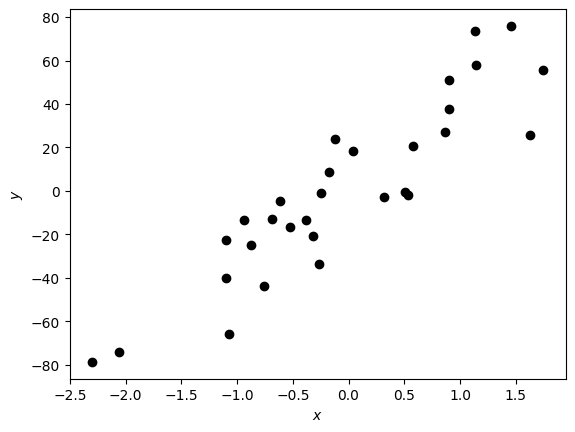

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
import numpy as np
import torch

# 데이터 생성
m = 30
X_np, y_np = make_regression(n_samples=m, n_features=1, noise=20, random_state=1)

# Pytorch 데이터 형태로 변환
X = torch.FloatTensor(X_np)
Y = torch.FloatTensor(y_np).view(-1, 1)

plt.scatter(X,  Y, c="black")

plt.xlabel("$x$")
plt.ylabel("$y$")

In [ ]:
print(X.shape)
print(Y.shape)

torch.Size([30, 1])
torch.Size([30, 1])


Plot the dataset:

<a name='2'></a>
## 2 - Implementation of the Neural Network Model for Linear Regression

Let's setup the neural network in a way which will allow to extend this simple case of a model to more complicated structures later.

<a name='2.3'></a>
### 2.3 - The Loop


**Instructions**:
- Look at the mathematical representation of your model :
\begin{align}
Z &=  w X + b\\
\hat{Y} &= Z,
\end{align}
- The steps you have to implement are:
    1. Retrieve each parameter from the dictionary "parameters"
    2. Implement Forward Propagation. Compute `Z` multiplying arrays `w`, `X` and adding vector `b`. Set the prediction array $A$ equal to $Z$.  


<a name='2.1'></a>
### 2.1 - Defining the Neural Network Structure

In [ ]:
import torch.nn as nn

# 1. 퍼셉트론 구조 정의 (은닉층 없음)
class Perceptron(nn.Module):
    def __init__(self):
        super(Perceptron, self).__init__()
        # 입력 1 -> 출력 1 (단일 선형 결합)
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

<a name='2.2'></a>
### 2.2 - Initialize the Model's Parameters

- 💡 팁: 왜 매번 값이 다른가요?
nn.Linear는 객체가 생성될 때마다 내부적으로 Kaiming He 초기화 또는 Xavier 초기화 변형 방식을 사용하여 가중치를 무작위로 설정
- 만약 연구나 협업을 위해 항상 동일한 초기 파라미터를 얻고 싶다면, 모델 생성 직전에 시드(Seed)를 고정

In [ ]:
# 매 번 초기화 값이 다르다.

# 1. 모델 인스턴스 생성
model = Perceptron()

# 2. 초기 파라미터 값 확인 (가중치 w, 편향 b)
# model.linear.weight와 model.linear.bias에 저장되어 있습니다.
w_initial = model.linear.weight.item()
b_initial = model.linear.bias.item()

print(f"--- 초기 파라미터 ---")
print(f"Initial Weight (w): {w_initial:.4f}")
print(f"Initial Bias (b): {b_initial:.4f}\n")


--- 초기 파라미터 ---
Initial Weight (w): 0.0581
Initial Bias (b): 0.6915



In [ ]:
# 3. 모델에 X를 입력하여 예측값(Y_hat) 계산

# PyTorch의 모델 객체를 함수처럼 호출하면 내부의 forward()가 실행됩니다.
with torch.no_grad(): # 예측 시에는 기울기 계산이 필요 없으므로 메모리 절약
    Y_hat = model(X)

# 4. 결과 확인 (상위 5개만 출력)
print("--- 초기 예측값 (Y_hat) 상위 5개 ---")
print(Y_hat[:5])

--- 초기 예측값 (Y_hat) 상위 5개 ---
tensor([[0.7100],
        [0.6292],
        [0.7417],
        [0.6814],
        [0.7579]])


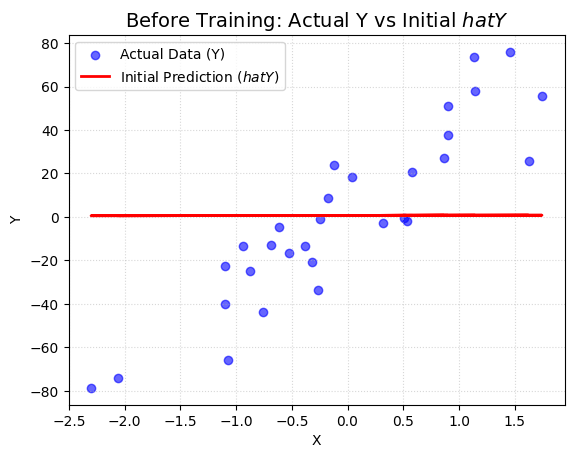

현재 가중치(w): 0.0581
현재 편향(b): 0.6915


In [ ]:
# 초기 파라미커로 예측하여 시각화
# 원본 데이터 산점도 (Actual Y)
plt.scatter(X_np, y_np, color='blue', alpha=0.6, label='Actual Data (Y)')

# 초기 모델의 예측선 (Initial Y_hat)
# Linear 모델이므로 두 점만 연결해도 직선이 나옵니다.
plt.plot(X_np, Y_hat, color='red', linewidth=2, label='Initial Prediction ($hat{Y}$)')

plt.title('Before Training: Actual Y vs Initial $hat{Y}$', fontsize=14)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

# 현재 파라미터 상태 출력
print(f"현재 가중치(w): {model.linear.weight.item():.4f}")
print(f"현재 편향(b): {model.linear.bias.item():.4f}")

Remember that your weights were just initialized with some random values, so the model has not been trained yet.

Define a cost function $(5)$ which will be used to train the model:

$$\mathcal{L}\left(w, b\right)  = \frac{1}{2m}\sum_{i=1}^{m} \left(\hat{y}^{(i)} - y^{(i)}\right)^2$$

In [ ]:
import torch.nn.functional as F

def calculate_mse(Y_hat, Y):
    """
    Calculates the Mean Squared Error (MSE) between Y_hat and Y.

    Arguments:
    Y_hat -- Predicted values (PyTorch tensor)
    Y -- True values (PyTorch tensor)

    Returns:
    mse -- Mean Squared Error
    """
    mse = F.mse_loss(Y_hat, Y)
    return mse

mse_value = calculate_mse(Y_hat, Y)
print(f"Mean Squared Error (MSE): {mse_value.item():.4f}")

Mean Squared Error (MSE): 1577.7871


You want to minimize the cost value, bringing it as close as possible to $0$, making your vector of predictions as similar to the training data as possible.

To achieve this, backward propagation needs to be performed. It is covered in details in the Course "Calculus" (Course 2 in the Specialization "Mathematics for Machine Learning"). For now you can use a function `train_nn()` from the uploaded toolbox to get the updated parameters in each step of the loop.

In [ ]:
import torch.optim as optim

# 1.모델 초기화(모델 인스턴스를 새로 생성: 가중치(w)와 편향(b)을 다시 무작위(Random) 상태로 되돌리는 것)
model = Perceptron()

# 2. 최적화 도구 초기화
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)


<a name='2.4'></a>
### 2.4 - Integrate all parts

In [ ]:
# 3. 반복 수행 (Loop)
epochs = 1000

for epoch in range(epochs):
    # 순전파
    prediction = model(X)
    loss = criterion(prediction, Y)

    # 역전파 및 업데이트
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 200 == 0:
        print(f'Epoch [{epoch+1}/1000], Loss: {loss.item():.4f}')

Epoch [200/1000], Loss: 282.8882
Epoch [400/1000], Loss: 282.4650
Epoch [600/1000], Loss: 282.4648
Epoch [800/1000], Loss: 282.4648
Epoch [1000/1000], Loss: 282.4648


In [ ]:
w_optimized = model.linear.weight.item()
b_optimized = model.linear.bias.item()

print(f"Optimized Weight (w): {w_optimized:.4f}")
print(f"Optimized Bias (b): {b_optimized:.4f}")

Optimized Weight (w): 35.7195
Optimized Bias (b): 2.2893


The final model parameters can be used for making predictions. Let's plot the linear regression line and some predictions. The regression line is red and the predicted points are blue.

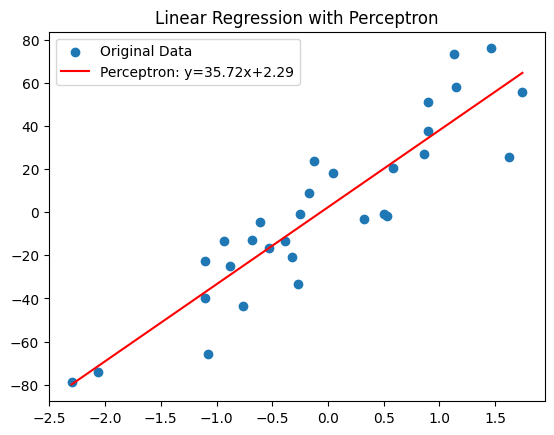

In [ ]:
# 4. 결과 시각화

# 회귀선 계산
x_range = np.array([X_np.min(), X_np.max()])
y_range = w_optimized * x_range + b_optimized

plt.scatter(X_np, y_np, label='Original Data')
plt.plot(x_range, y_range, color='red', label=f'Perceptron: y={w_optimized:.2f}x+{b_optimized:.2f}')
plt.title("Linear Regression with Perceptron")
plt.legend()
plt.show()

Not bad for such a small neural network with just a single perceptron and one input node!

<a name='3'></a>
## 3 - Multiple Linear Regression
Models are not always as simple as the one above. In some cases your output is dependent on more than just one variable. Let's look at the case where the output depends on two input variables.

![](https://i.sstatic.net/BmcZU.png)

<a name='3.1'></a>
### 3.1 - Multipe Linear Regression Model

Multiple linear regression model with two independent variables $x_1$, $x_2$ can be written as

$$\hat{y} = w_1x_1 + w_2x_2 + b = Wx + b,\tag{6}$$

where $Wx$ is the dot product of the input vector $x = \begin{bmatrix} x_1 & x_2\end{bmatrix}$ and parameters vector $W = \begin{bmatrix} w_1 & w_2\end{bmatrix}$, scalar parameter $b$ is the intercept.

The goal is the same - find the "best" parameters $w_1$, $w_2$ and $b$ such the differences between original values $y_i$ and predicted values $\hat{y}_i$ are minimum.

You can use a slightly more complicated neural network model to do that. Now matrix multiplication will be in the core of the model!

<a name='3.2'></a>
### 3.2 - Neural Network Model with a Single Perceptron and Two Input Nodes

Again, you will use only one perceptron, but with two input nodes shown in the following scheme:

The perceptron output calculation for every training example $x^{(i)} = \begin{bmatrix} x_1^{(i)} & x_2^{(i)}\end{bmatrix}$ can be written with dot product:

$$z^{(i)} = w_1x_1^{(i)} + w_2x_2^{(i)} + b = Wx^{(i)} + b,\tag{7}$$

where weights are in the vector $W = \begin{bmatrix} w_1 & w_2\end{bmatrix}$ and bias $b$ is a scalar. The output layer will have the same single node $\hat{y}^{(i)} = z^{(i)}$.

Organise all training examples in a matrix $X$ of a shape ($2 \times m$), putting $x_1^{(i)}$ and $x_2^{(i)}$ into columns. Then matrix multiplication of $W$ ($1 \times 2$) and $X$ ($2 \times m$) will give a ($1 \times m$) vector

$$WX =
\begin{bmatrix} w_1 & w_2\end{bmatrix}
\begin{bmatrix}
x_1^{(1)} & x_1^{(2)} & \dots & x_1^{(m)} \\
x_2^{(1)} & x_2^{(2)} & \dots & x_2^{(m)} \\ \end{bmatrix}
=\begin{bmatrix}
w_1x_1^{(1)} + w_2x_2^{(1)} &
w_1x_1^{(2)} + w_2x_2^{(2)} & \dots &
w_1x_1^{(m)} + w_2x_2^{(m)}\end{bmatrix}.$$

And the model can be written as

\begin{align}
Z &=  W X + b,\\
\hat{Y} &= Z,
\tag{8}\end{align}

where $b$ is broadcasted to the vector of a size ($1 \times m$). These are the calculations to perform in the forward propagation step. Cost function will remain the same, and there will be no change in methodology and training (that will be discussed in the next Course)!

<a name='3.3'></a>
### 3.3 - Dataset

Let's build a linear regression model for a Kaggle dataset [House Prices](https://www.kaggle.com/c/house-prices-advanced-regression-techniques), saved in a file `train.csv`. You will use two fields - ground living area (`GrLivArea`, square feet) and rates of the overall quality of material and finish (`OverallQual`, 1-10) to predict sales price (`SalePrice`, dollars).

To open the dataset you can use `pandas` function `read_csv`:

In [ ]:
df = pd.read_csv('train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


The data is now saved in the variable `df` as a **DataFrame**, which is the most commonly used `pandas` object. It is a 2-dimensional labeled data structure with columns of potentially different types. You can think of it as a table or a spreadsheet. Full documentation can be found [here](https://pandas.pydata.org/).

Select the required fields and save them in the variables `X_multi`, `Y_multi`:

In [ ]:
X_multi = df[['GrLivArea', 'OverallQual']]
Y_multi = df['SalePrice']

Have a look at the data:

In [ ]:
print(f"X_multi:\n{X_multi}\n")
print(f"Y_multi:\n{Y_multi}\n")

X_multi:
      GrLivArea  OverallQual
0          1710            7
1          1262            6
2          1786            7
3          1717            7
4          2198            8
...         ...          ...
1455       1647            6
1456       2073            6
1457       2340            7
1458       1078            5
1459       1256            5

[1460 rows x 2 columns]

Y_multi:
0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64



All of the original arrays have different units. To make training of the neural network efficient, you need to bring them to the same units. A common approach to it is called **normalization**: substract the mean value of the array from each of the elements in the array and divide them by standard deviation (a statistical measure of the amount of dispersion of a set of values). If you are not familiar with mean and standard deviation, do not worry about this for now - this is covered in the third Course of Specialization.

Normalization is implemented in the following code:

In [ ]:
X_multi_norm = (X_multi - X_multi.mean())/X_multi.std()
Y_multi_norm = (Y_multi - Y_multi.mean())/Y_multi.std()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. 데이터 준비
# X_multi_norm: (2, 1460) -> (1460, 2)로 변환 필요
# Y_multi_norm: (1, 1460) -> (1460, 1)로 변환 필요
X_tensor = torch.FloatTensor(X_multi_norm.values) # Convert DataFrame to NumPy array first
Y_tensor = torch.FloatTensor(Y_multi_norm.values).view(-1, 1) # Convert Series to NumPy array and reshape

# 2. 모델 정의 (입력 unit: 2, 출력 unit: 1)
class MultiPerceptron(nn.Module):
    def __init__(self):
        super(MultiPerceptron, self).__init__()
        self.linear = nn.Linear(2, 1)

    def forward(self, x):
        return self.linear(x)

model = MultiPerceptron()
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01) # Reduced learning rate

# 3. 학습 루프
epochs = 2000

for epoch in range(epochs):
    # 순전파 (퍼셉트론 출력 계산)
    prediction = model(X_tensor)
    loss = criterion(prediction, Y_tensor)

    # 역전파 및 업데이트 (기울기 계산 및 파라미터 보정)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 200회마다 손실값 출력
    if (epoch + 1) % 200 == 0:
        print(f'Epoch [{epoch+1}/1000], Loss: {loss.item():.4f}')

Epoch [200/1000], Loss: 0.2910
Epoch [400/1000], Loss: 0.2858
Epoch [600/1000], Loss: 0.2856
Epoch [800/1000], Loss: 0.2856
Epoch [1000/1000], Loss: 0.2856
Epoch [1200/1000], Loss: 0.2856
Epoch [1400/1000], Loss: 0.2856
Epoch [1600/1000], Loss: 0.2856
Epoch [1800/1000], Loss: 0.2856
Epoch [2000/1000], Loss: 0.2856


In [ ]:
w1_optimized = model.linear.weight[0, 0].item()
w2_optimized = model.linear.weight[0, 1].item()
b_optimized = model.linear.bias.item()

print(f"Optimized Weight 1 (w1): {w1_optimized:.4f}")
print(f"Optimized Weight 2 (w2): {w2_optimized:.4f}")
print(f"Optimized Bias (b): {b_optimized:.4f}")

Optimized Weight 1 (w1): 0.3695
Optimized Weight 2 (w2): 0.5719
Optimized Bias (b): 0.0000


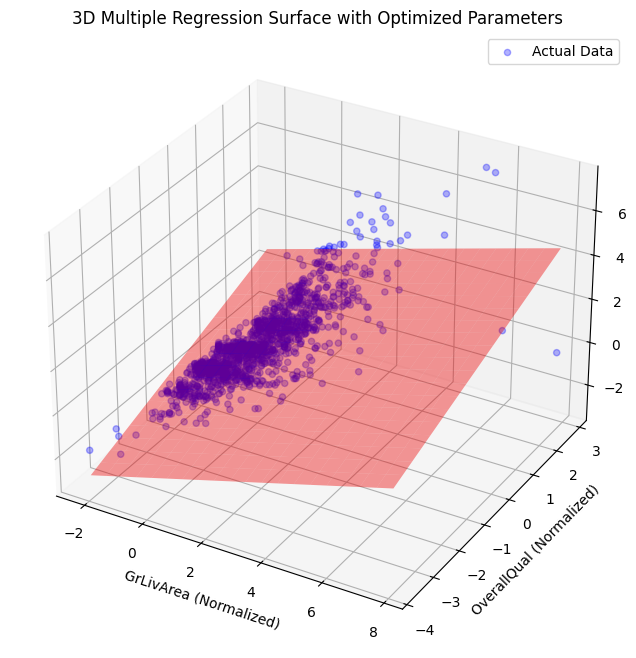

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # 3D 시각화용
import numpy as np

# 4. 3D 시각화 (특성이 2개이므로 평면으로 시각화)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 원본 데이터 (Blue dots) - NumPy 배열로 변환
ax.scatter(X_multi_norm['GrLivArea'].values, X_multi_norm['OverallQual'].values, Y_multi_norm.values,
           color='blue', alpha=0.3, label='Actual Data')

# 회귀 평면 예측을 위한 그리드 생성
x1_range = np.linspace(X_multi_norm['GrLivArea'].min(), X_multi_norm['GrLivArea'].max(), 20)
x2_range = np.linspace(X_multi_norm['OverallQual'].min(), X_multi_norm['OverallQual'].max(), 20)
X1_mesh, X2_mesh = np.meshgrid(x1_range, x2_range)

# 최적화된 파라미터
w1 = w1_optimized
w2 = w2_optimized
b = b_optimized

# 평면 위의 점들 예측
Y_surf = w1 * X1_mesh + w2 * X2_mesh + b

# 회귀 평면 시각화 (Red surface)
ax.plot_surface(X1_mesh, X2_mesh, Y_surf, color='red', alpha=0.4)

ax.set_xlabel('GrLivArea (Normalized)')
ax.set_ylabel('OverallQual (Normalized)')
ax.set_zlabel('SalePrice (Normalized)')
plt.title('3D Multiple Regression Surface with Optimized Parameters')
plt.legend()
plt.show()

## **실습과제**

Remember, that the initial datasets were normalized. To make the predictions, you need to normalize the original, calculate predictions with the obtained linear regression coefficients and then **denormalize** the result (perform the reverse process of normalization):

In [ ]:
# 1. 예측할 새로운 데이터 준비
X_raw_input_np = np.array([[1710, 7], [1200, 6], [2200, 8]])

# 2. X_multi의 평균과 표준편차를 사용하여 새로운 데이터를 정규화
# X_raw_input_np를 DataFrame으로 변환하여 X_multi의 컬럼과 정렬
X_pred_df = pd.DataFrame(X_raw_input_np, columns=['GrLivArea', 'OverallQual'])
X_pred_multi_norm = (X_pred_df - X_multi.mean()) / X_multi.std()

# 3. 정규화된 데이터를 PyTorch 텐서로 변환
X_pred_tensor = torch.FloatTensor(X_pred_multi_norm.values)

# 4. 모델을 사용하여 예측 수행
# 모델을 평가 모드로 설정
model.eval()
with torch.no_grad(): # 기울기 계산을 비활성화하여 메모리 절약 및 연산 속도 향상
    Y_pred_norm_tensor = model(X_pred_tensor)

# 5. 예측 결과를 NumPy 배열로 변환
Y_pred_norm_np = Y_pred_norm_tensor.numpy()

# 6. Y_multi의 평균과 표준편차를 사용하여 예측 결과를 역정규화
Y_pred_multi = Y_pred_norm_np * Y_multi.std() + Y_multi.mean()

# 7. 결과 출력
print(f"Ground living area, square feet:\n{X_raw_input_np[:, 0]}")
print(f"Rates of the overall quality of material and finish, 1-10:\n{X_raw_input_np[:, 1]}")
print(f"Predictions of sales price, $:\n{np.round(Y_pred_multi.flatten())}")

Ground living area, square feet:
[1710 1200 2200]
Rates of the overall quality of material and finish, 1-10:
[7 6 8]
Predictions of sales price, $:
[221375. 160036. 281597.]


Congrats on finishing this programming assignment!